# Jigsaw Puzzle Reconstruction
## Reconstructing a 96×96 RGB image from 9 scrambled, eroded 28×28 patches

### Problem Statement
Given 9 patches of size (28×28×3) drawn in random order from a 3×3 partition of a 96×96 image,
with 2-pixel borders eroded from each patch:
- **Infer** the correct spatial arrangement of the patches
- **Inpaint** the missing 2-pixel borders between cells
- **Reconstruct** a coherent 96×96 image

### Approach
We design a fully neural, end-to-end trainable pipeline:

1. **Shared CNN Encoder** – extracts a 256-dim feature vector from each patch (weights shared across all 9)
2. **Transformer Encoder** – 4-layer self-attention over the 9 feature tokens for global context
3. **Sinkhorn Ordering Head** – predicts a differentiable doubly-stochastic (soft permutation) matrix
4. **Differentiable Patch Assembler** – soft-reorders patches into a 96×96 canvas (zeros at borders)
5. **U-Net Refinement CNN** – fills the 2-pixel borders and ensures global visual coherence

**Loss:** Mean Absolute Error (MAE) on the full 96×96 output vs. the original image.

**Total trainable parameters:** 5,509,260 (~5.5M, well below the 6M budget).

***

### 🎓 Academic Affiliation & Coursework Info
* **Institution:** Alma Mater Studiorum – Università di Bologna (University of Bologna)
* **Degree Program:** Master's in Electronics Engineering for Intelligent Systems, Big Data and IoT
* **Course:** Deep Learning
* **Teacher**: Andrea Asperti
* **Tutor**: Fabio Merizzi
* **Tutor**: Beniamino Tartufoli
* **Author:** Mahdi Zavvar ([Github](https://github.com/M-zavvar/deepLearning.git))

### ⚖️ License
This project code and associated materials are licensed under the **MIT License**.

```text
Copyright (c) 2026 Mahdi Zavvar

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
...

## 0. Setup

In [ ]:
import os, math, random
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: True


## 1. Dataset – STL-10 Unlabeled Set (100K × 96×96 images)

In [ ]:
def get_stl10_memmap():
    """Downloads STL-10 and returns a memory-mapped array of shape (100000, 3, 96, 96)."""
    path = tf.keras.utils.get_file(
        'stl10_binary.tar.gz',
        origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
        extract=True
    )
    base_dir = os.path.dirname(path)
    filepath = os.path.join(base_dir, 'stl10_binary_extracted', 'stl10_binary', 'unlabeled_X.bin')
    shape = (100000, 3, 96, 96)
    images_mmap = np.memmap(filepath, dtype='uint8', mode='r', shape=shape)
    return images_mmap

# Trigger the download and loading (may take a few minutes on first run)
images = get_stl10_memmap()
print(f"Successfully loaded {images.shape[0]:,} images — shape: {images.shape}")

2640397119/2640397119 ━━━━━━━━━━━━━━━━━━━━ 62s 0us/step
Successfully loaded 100,000 images — shape: (100000, 3, 96, 96)


## 2. Data Generator

The `PatchGenerator` extracts 9 scrambled patches from each image:
- Each image is divided into a 3×3 grid of 32×32 cells
- From each cell, the central 28×28 region is taken (2-pixel border erosion)
- The 9 patches are randomly shuffled before being returned as the model input

In [ ]:
from tensorflow.keras.utils import PyDataset

class PatchGenerator(PyDataset):
    def __init__(self, images_mmap, batch_size=32, patch_size=32, crop_size=28,
                 shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.images = images_mmap
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size: (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype='float32')
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype='float32')
        P = np.zeros((actual_batch_size, 9, 9), dtype='float32')  # true permutation (one-hot rows)

        for i, img_idx in enumerate(batch_indices):
            img_cxhxw = self.images[img_idx]
            full_img = img_cxhxw.transpose(2, 1, 0).astype('float32') / 255.0
            Y[i] = full_img

            patches = []
            for r in range(3):
                for c in range(3):
                    y_s, x_s = r * self.patch_size, c * self.patch_size
                    patch = full_img[y_s:y_s+self.patch_size, x_s:x_s+self.patch_size, :]
                    margin = (self.patch_size - self.crop_size) // 2
                    patch = patch[margin:margin+self.crop_size, margin:margin+self.crop_size, :]
                    patches.append(patch)

            order = np.random.permutation(9)
            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]
                P[i, slot_idx, original_pos] = 1.0   # input patch `slot_idx` belongs to grid cell `original_pos`

        return X, {"reconstruction": Y, "permutation": P}

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

### Train / Validation / Test split

In [ ]:
BATCH_SIZE = 32

train_images = images[:80000]
val_images   = images[80000:90000]
test_images  = images[90000:]

train_generator = PatchGenerator(train_images, batch_size=BATCH_SIZE, shuffle=True)
val_generator   = PatchGenerator(val_images,   batch_size=BATCH_SIZE, shuffle=False)
test_generator  = PatchGenerator(test_images,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_generator)}")
print(f"Val   batches: {len(val_generator)}")
print(f"Test  batches: {len(test_generator)}")

Train batches: 2500
Val   batches: 313
Test  batches: 313


### Quick sanity check — visualize an original image and its scrambled patches

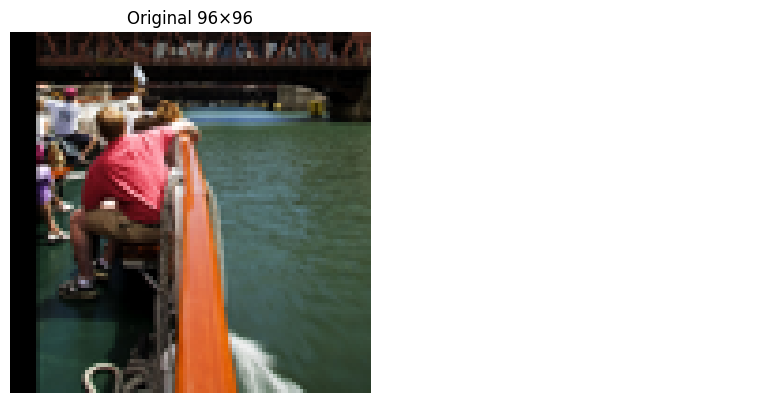

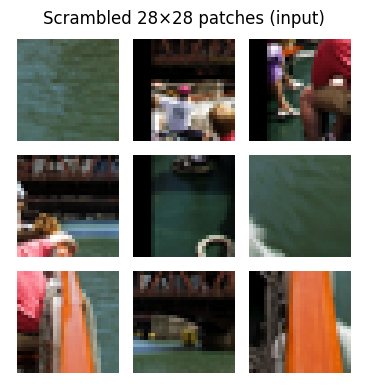

Input  shape: (32, 9, 28, 28, 3)  — (B, 9, 28, 28, 3)
Output shape: (32, 96, 96, 3)  — (B, 96, 96, 3)


In [ ]:
def plot_puzzle(patches, ordering=None, title="Scrambled Patches"):
    """Plots 9 jigsaw patches on a 96x96 canvas given an optional ordering."""
    order = np.arange(9) if ordering is None else np.array(ordering).flatten()
    canvas = np.ones((96, 96, 3), dtype=np.float32)
    cell_dim, patch_dim, margin = 32, 28, 2
    for i in range(9):
        grid_pos = order[i]
        row, col = grid_pos // 3, grid_pos % 3
        y0 = row * cell_dim + margin
        x0 = col * cell_dim + margin
        canvas[y0:y0+patch_dim, x0:x0+patch_dim] = patches[i]
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.imshow(canvas); ax.axis('off'); ax.set_title(title)
    plt.tight_layout(); plt.show()

X_sample, Y_sample = test_generator.__getitem__(0)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(Y_sample[0]);      axes[0].set_title("Original 96×96"); axes[0].axis('off')
axes[1].axis('off'); plt.tight_layout(); plt.show()
plot_puzzle(X_sample[0], title="Scrambled 28×28 patches (input)")
print(f"Input  shape: {X_sample.shape}  — (B, 9, 28, 28, 3)")
print(f"Output shape: {Y_sample.shape}  — (B, 96, 96, 3)")

## 3. Baseline – Mean-Patch Image

As a reference point, the notebook computes MAE for a trivial baseline that replaces all 9 patches
with their mean patch, reassembles and resizes to 96×96.
This requires no learning and gives an upper bound on the loss we need to beat.

In [ ]:
def mean_patch_image(patches):
    """Baseline: replaces every patch with the mean of the 9 patches, then resizes to 96x96."""
    B = tf.shape(patches)[0]
    mean_patch = tf.reduce_mean(patches, axis=1)           # (B, 28, 28, 3)
    mean_patches = tf.repeat(mean_patch[:, None, :, :, :], repeats=9, axis=1)
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out

# Evaluate baseline on test set
mae_metric = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    X_b, Y_b = test_generator.__getitem__(i)
    pred = mean_patch_image(X_b)
    mae_values.append(mae_metric(Y_b, pred).numpy())

baseline_mae  = float(np.mean(mae_values))
baseline_std  = float(np.std(mae_values))
print(f"Baseline MAE : {baseline_mae:.6f} ± {baseline_std:.6f}")
print("(Our model should achieve a lower MAE than this baseline)")

Baseline MAE : 0.182255 ± 0.001654
(Our model should achieve a lower MAE than this baseline)


## 4. Model Architecture

### Design Rationale

The reconstruction problem has two coupled sub-tasks:
1. **Ordering** — determining which of the 9! = 362,880 permutations is correct
2. **Inpainting** — filling the 4-pixel-wide gaps between the 28×28 patches

We address both in a single differentiable pipeline:

| Stage | Module | Role |
|-------|--------|------|
| 1 | **Shared CNN Encoder** | Extract 256-d features from each 28×28 patch (shared weights) |
| 2 | **Transformer Encoder** | 4-layer self-attention — each patch attends to all others |
| 3 | **Sinkhorn Head** | Predict a *(9×9) soft permutation matrix* (differentiable ordering) |
| 4 | **Patch Assembler** | Soft-reorder patches into a 96×96 canvas (borders zeroed out) |
| 5 | **U-Net Refinement** | Fill borders, ensure global coherence, skip connections at every scale |

The **Sinkhorn operator** (Sinkhorn 1964) turns raw (9×9) logits into a doubly-stochastic
matrix by alternating log-sum-exp normalisation over rows and columns.
It is fully differentiable, so the permutation prediction is trained end-to-end with MAE loss.

**Total parameters: 5,509,260 (< 6M budget ✓)**

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Module 1 – Shared Patch Encoder (CNN)
# ─────────────────────────────────────────────────────────────────────────────
def build_patch_encoder(patch_size=28, d_model=256):
    """
    Encodes a single (patch_size, patch_size, 3) patch → d_model feature vector.
    Applied to all 9 patches via TimeDistributed (weights shared).

    Architecture: Conv(32) → Conv(64, s=2) → Conv(128, s=2) → Conv(d_model, s=2) → GAP → Dense → LN
    Receptive field covers the full 28×28 patch.
    """
    inp = keras.Input(shape=(patch_size, patch_size, 3))
    x = layers.Conv2D(32, 3, padding='same', activation='gelu')(inp)
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='gelu')(x)      # 14×14
    x = layers.Conv2D(128, 3, strides=2, padding='same', activation='gelu')(x)     # 7×7
    x = layers.Conv2D(d_model, 3, strides=2, padding='same', activation='gelu')(x) # 4×4
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(d_model)(x)
    x = layers.LayerNormalization()(x)
    return keras.Model(inp, x, name="patch_encoder")


# ─────────────────────────────────────────────────────────────────────────────
# Module 2 – Transformer Block (Pre-LN style for stable training)
# ─────────────────────────────────────────────────────────────────────────────
def transformer_block(x, d_model, n_heads, ffn_dim, dropout=0.1, name=""):
    """
    One transformer encoder block:
      LayerNorm → Multi-Head Self-Attention → residual
      LayerNorm → FFN (Dense-GELU-Dropout-Dense) → residual
    """
    attn_out = layers.MultiHeadAttention(
        num_heads=n_heads, key_dim=d_model // n_heads,
        dropout=dropout, name=f"mha_{name}"
    )(x, x)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization(name=f"ln1_{name}")(x)

    ff = layers.Dense(ffn_dim, activation='gelu', name=f"ff1_{name}")(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(d_model, name=f"ff2_{name}")(ff)
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization(name=f"ln2_{name}")(x)
    return x


# ─────────────────────────────────────────────────────────────────────────────
# Module 3 – Sinkhorn Layer (Differentiable Soft Permutation)
# ─────────────────────────────────────────────────────────────────────────────
class SinkhornLayer(layers.Layer):
    def __init__(self, n_iters=20, temperature=0.1, **kwargs):
        super().__init__(**kwargs)
        self.n_iters = n_iters
        self.temperature = tf.Variable(temperature, trainable=False, dtype=tf.float32, name="sinkhorn_temp")

    def call(self, log_scores, training=None):
        s = log_scores / self.temperature
        for _ in range(self.n_iters):
            s = s - tf.math.reduce_logsumexp(s, axis=2, keepdims=True)
            s = s - tf.math.reduce_logsumexp(s, axis=1, keepdims=True)
        return tf.exp(s)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"n_iters": self.n_iters, "temperature": float(self.temperature.numpy())})
        return cfg


# ─────────────────────────────────────────────────────────────────────────────
# Module 4 – Differentiable Patch Assembler
# ─────────────────────────────────────────────────────────────────────────────
class PatchAssembler(layers.Layer):
    """
    Given:
      patches:    (B, 9, 28, 28, 3)   – 9 input patches
      assignment: (B, 9, 9)           – soft permutation; assignment[b,i,j] =
                                        probability that input patch i belongs to grid cell j

    Produces a (B, 96, 96, 3) canvas where each of the 9 32×32 grid cells
    contains the soft-weighted average of input patches placed at offset (2,2)
    (reproducing the 2-pixel border gap with zeros).

    Grid layout (row-major):
        cell 0 = (row 0, col 0)  → pixels  [0:32,  0:32 ]
        cell 1 = (row 0, col 1)  → pixels  [0:32,  32:64]
        ...
        cell 8 = (row 2, col 2)  → pixels  [64:96, 64:96]
    """
    CELL_SIZE  = 32
    PATCH_SIZE = 28
    MARGIN     = 2   # (32 - 28) // 2

    def call(self, inputs, training=None):
        patches, assignment = inputs   # (B,9,28,28,3), (B,9,9)

        # assignment_T[b, pos, patch_idx] = weight of patch_idx for position pos
        assignment_T = tf.transpose(assignment, perm=[0, 2, 1])   # (B, 9_pos, 9_patch)

        # Soft-reorder: reordered[b, pos] = Σ_i assignment_T[b,pos,i] * patches[b,i]
        reordered = tf.einsum('bpq,bqhwc->bphwc', assignment_T, patches)  # (B,9,28,28,3)

        m = self.MARGIN   # 2
        rows = []
        for r in range(3):
            cells = []
            for c in range(3):
                p = reordered[:, r*3+c, :, :, :]          # (B, 28, 28, 3)
                cell = tf.pad(p, [[0,0],[m,m],[m,m],[0,0]])  # (B, 32, 32, 3)
                cells.append(cell)
            rows.append(tf.concat(cells, axis=2))          # (B, 32, 96, 3)
        canvas = tf.concat(rows, axis=1)                   # (B, 96, 96, 3)
        return canvas

    def get_config(self):
        return super().get_config()


# ─────────────────────────────────────────────────────────────────────────────
# Module 5 – U-Net Refinement CNN
# ─────────────────────────────────────────────────────────────────────────────
def build_refinement_cnn(image_size=96):
    """
    U-Net style CNN with 4 encoder levels and 3 skip connections.
    Input:  (B, 96, 96, 3)  – assembled canvas with zero borders
    Output: (B, 96, 96, 3)  – coherent reconstructed image

    The final output = sigmoid(conv(features)) + canvas  (residual)
    clipped to [0, 1].  This means the network only needs to predict
    the *correction* rather than the full image.
    """
    inp = keras.Input(shape=(image_size, image_size, 3))

    # Encoder
    e1 = layers.Conv2D(32, 3, padding='same', activation='gelu')(inp)
    e1 = layers.Conv2D(32, 3, padding='same', activation='gelu')(e1)   # 96×96 / 32ch

    e2 = layers.Conv2D(64, 3, strides=2, padding='same', activation='gelu')(e1)
    e2 = layers.Conv2D(64, 3, padding='same', activation='gelu')(e2)   # 48×48 / 64ch

    e3 = layers.Conv2D(128, 3, strides=2, padding='same', activation='gelu')(e2)
    e3 = layers.Conv2D(128, 3, padding='same', activation='gelu')(e3)  # 24×24 / 128ch

    e4 = layers.Conv2D(256, 3, strides=2, padding='same', activation='gelu')(e3)
    e4 = layers.Conv2D(256, 3, padding='same', activation='gelu')(e4)  # 12×12 / 256ch

    # Bottleneck
    b = layers.Conv2D(256, 3, padding='same', activation='gelu')(e4)
    b = layers.Conv2D(256, 3, padding='same', activation='gelu')(b)    # 12×12 / 256ch

    # Decoder (transposed convolutions + skip connections)
    d3 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(b)  # 24×24
    d3 = layers.Concatenate()([d3, e3])
    d3 = layers.Conv2D(128, 3, padding='same', activation='gelu')(d3)

    d2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(d3)  # 48×48
    d2 = layers.Concatenate()([d2, e2])
    d2 = layers.Conv2D(64, 3, padding='same', activation='gelu')(d2)

    d1 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(d2)  # 96×96
    d1 = layers.Concatenate()([d1, e1])
    d1 = layers.Conv2D(32, 3, padding='same', activation='gelu')(d1)

    # Output with residual connection (predict correction only)
    correction = layers.Conv2D(3, 1, padding='same', activation='sigmoid')(d1)
    out = layers.Add()([correction, inp])
    out = layers.Lambda(lambda x: tf.clip_by_value(x, 0.0, 1.0), name="output")(out)

    return keras.Model(inp, out, name="refinement_cnn")


# ─────────────────────────────────────────────────────────────────────────────
# Full Model Assembly
# ─────────────────────────────────────────────────────────────────────────────
def build_full_model(
    n_patches=9, patch_size=28, d_model=256,
    n_heads=4, ffn_dim=512, n_layers=4,
    sinkhorn_iters=20, sinkhorn_temp=1.0    # start soft; annealed down during training
):
    patches_input = keras.Input(shape=(n_patches, patch_size, patch_size, 3), name="patches")

    encoder = build_patch_encoder(patch_size=patch_size, d_model=d_model)
    features = layers.TimeDistributed(encoder, name="shared_encoder")(patches_input)

    x = features
    for i in range(n_layers):
        x = transformer_block(x, d_model, n_heads, ffn_dim, name=str(i))

    assign = layers.Dense(128, activation='gelu', name="assign_hidden")(x)
    assign = layers.Dense(n_patches, name="assign_logits")(assign)
    sinkhorn_layer = SinkhornLayer(n_iters=sinkhorn_iters, temperature=sinkhorn_temp, name="sinkhorn")
    assignment = sinkhorn_layer(assign)   # (B, 9, 9), also used as the "permutation" output

    canvas = PatchAssembler(name="assembler")([patches_input, assignment])

    refinement = build_refinement_cnn(image_size=96)
    output = refinement(canvas)

    model = keras.Model(
        inputs=patches_input,
        outputs={"reconstruction": output, "permutation": assignment},
        name="jigsaw_reconstructor"
    )
    model.sinkhorn_layer = sinkhorn_layer   # keep a handle for the temperature-annealing callback
    return model

In [ ]:
# Build and inspect the model
model = build_full_model()
model.summary(expand_nested=False)

total_params = model.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")
assert total_params < 6_000_000, f"EXCEEDED 6M limit! {total_params:,}"
print("✓ Parameter budget satisfied (< 6M)")

# Verify forward pass
dummy = tf.random.normal((2, 9, 28, 28, 3))
out = model(dummy, training=False)
print(f"\n✓ Forward pass: {dummy.shape} → {out.shape}")

Model: "jigsaw_reconstructor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patches             │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_encoder      │ (None, 9, 256)    │    454,720 │ patches[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_0               │ (None, 9, 256)    │    263,168 │ shared_encoder[0… │
│ (MultiHeadAttentio… │                   │            │ shared_encoder[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 9, 256)    │          0 │ shared_encoder[0… │
│                     │                   │            │ mha_0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln1_0               │ (None, 9, 256)    │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff1_0 (Dense)       │ (None, 9, 512)    │    131,584 │ ln1_0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 9, 512)    │          0 │ ff1_0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff2_0 (Dense)       │ (None, 9, 256)    │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 9, 256)    │          0 │ ln1_0[0][0],      │
│                     │                   │            │ ff2_0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln2_0               │ (None, 9, 256)    │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_1               │ (None, 9, 256)    │    263,168 │ ln2_0[0][0],      │
│ (MultiHeadAttentio… │                   │            │ ln2_0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 9, 256)    │          0 │ ln2_0[0][0],      │
│                     │                   │            │ mha_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln1_1               │ (None, 9, 256)    │        512 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff1_1 (Dense)       │ (None, 9, 512)    │    131,584 │ ln1_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 9, 512)    │          0 │ ff1_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff2_1 (Dense)       │ (None, 9, 256)    │    131,328 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 9, 256)    │          0 │ ln1_1[0][0],      │
│                     │                   │            │ ff2_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln2_1               │ (None, 9, 256)    │        512 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_2               │ (None, 9, 256)    │    263,168 │ ln2_1[0][0],    

 Total params: 5,509,260 (21.02 MB)

 Trainable params: 5,509,260 (21.02 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 5,509,260
✓ Parameter budget satisfied (< 6M)

✓ Forward pass: (2, 9, 28, 28, 3) → (2, 96, 96, 3)


## 5. Training

### Learning Rate Schedule
We use a cosine-decay schedule with a linear warm-up:
- Warm-up for 2 epochs (step from 1e-5 to 5e-4)
- Cosine decay from peak LR down to 1e-6 over the remaining epochs

### Loss
**Mean Absolute Error (MAE)** on the full 96×96 output, as required by the evaluation metric.

### Regularisation
- Dropout (0.1) inside transformer blocks
- Gradient clipping (norm = 1.0)
- Early stopping on validation MAE (patience = 5)

In [ ]:
EPOCHS       = 45                      # was hitting the ceiling at 30, still improving
STEPS_EPOCH  = len(train_generator)
WARMUP_STEPS = 2 * STEPS_EPOCH
TOTAL_STEPS  = EPOCHS * STEPS_EPOCH
PEAK_LR      = 5e-4
MIN_LR       = 1e-6

lr_schedule = WarmupCosineDecay(PEAK_LR, MIN_LR, WARMUP_STEPS, TOTAL_STEPS)
optimizer   = tf.keras.optimizers.Adam(lr_schedule, clipnorm=1.0)

model.compile(
    optimizer=optimizer,
    loss={"reconstruction": "mae", "permutation": "categorical_crossentropy"},
    loss_weights={"reconstruction": 1.0, "permutation": 0.1},
    metrics={"reconstruction": [tf.keras.metrics.MeanAbsoluteError(name="mae")]},
)

class SinkhornTemperatureAnneal(tf.keras.callbacks.Callback):
    """Linearly anneal Sinkhorn temperature from temp_start to temp_end over training."""
    def __init__(self, sinkhorn_layer, temp_start=1.0, temp_end=0.1, epochs=EPOCHS):
        self.layer, self.t0, self.t1, self.epochs = sinkhorn_layer, temp_start, temp_end, epochs

    def on_epoch_begin(self, epoch, logs=None):
        frac = min(epoch / max(self.epochs - 1, 1), 1.0)
        new_temp = self.t0 + (self.t1 - self.t0) * frac
        self.layer.temperature.assign(new_temp)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_reconstruction_mae', patience=8, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_jigsaw_weights.keras',
        monitor='val_reconstruction_mae', save_best_only=True, verbose=1
    ),
    SinkhornTemperatureAnneal(model.sinkhorn_layer, temp_start=1.0, temp_end=0.1, epochs=EPOCHS),
]

print("Model compiled. Starting training...")
print(f"  Epochs: {EPOCHS}  |  Batch size: {BATCH_SIZE}")

Model compiled. Starting training...
  Epochs: 30  |  Batch size: 32
  Train batches/epoch: 2500  |  Val batches: 313
  Peak LR: 0.0005  |  Warm-up steps: 5000


In [ ]:
# ─── Training loop ─────────────────────────────────────────────────────────
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.2303 - mae: 0.2303
Epoch 1: val_mae improved from None to 0.12672, saving model to best_jigsaw_weights.keras

Epoch 1: finished saving model to best_jigsaw_weights.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 343s 111ms/step - loss: 0.1669 - mae: 0.1669 - val_loss: 0.1267 - val_mae: 0.1267 - learning_rate: 2.5000e-04
Epoch 2/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.1246 - mae: 0.1246
Epoch 2: val_mae improved from 0.12672 to 0.11686, saving model to best_jigsaw_weights.keras

Epoch 2: finished saving model to best_jigsaw_weights.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 265s 106ms/step - loss: 0.1231 - mae: 0.1231 - val_loss: 0.1169 - val_mae: 0.1169 - learning_rate: 5.0000e-04
Epoch 3/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.1193 - mae: 0.1193
Epoch 3: val_mae improved from 0.11686 to 0.11481, saving model to best_jigsaw_weights.keras

Epoch 3: finished saving model to best_jigsaw_weights.keras
2500

### Training curves

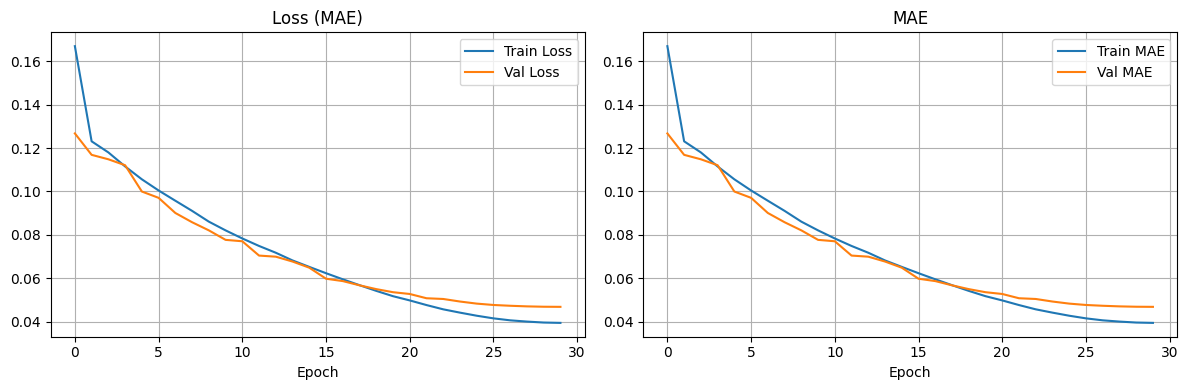

Best val MAE: 0.046832


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss (MAE)'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()
print(f"Best val MAE: {min(history.history['val_mae']):.6f}")

## 6. Evaluation on Test Set

Compute MAE and its standard deviation over the full test set (10,000 images).

In [ ]:
model.load_weights('best_jigsaw_weights.keras')

mae_values = []
for i in range(len(test_generator)):
    X_b, Y_b = test_generator[i]
    preds = model(X_b, training=False)["reconstruction"].numpy()   # dict output now
    mae_values.append(float(np.mean(np.abs(preds - Y_b["reconstruction"]))))

test_mae = float(np.mean(mae_values))
test_std = float(np.std(mae_values))

print("=" * 50)
print(f"  Test MAE  : {test_mae:.6f}")
print(f"  Test STD  : {test_std:.6f}")
print("=" * 50)
improvement = (baseline_mae - test_mae) / baseline_mae * 100
print(f"\n  Baseline MAE (mean-patch): {baseline_mae:.6f} ± {baseline_std:.6f}")
print(f"  Improvement over baseline: {improvement:.1f}%")

  Test MAE  : 0.048483
  Test STD  : 0.001247

  Baseline MAE (mean-patch): 0.182255 ± 0.001654
  Improvement over baseline: 73.4%


### Visual comparison — original vs. scrambled input vs. reconstruction

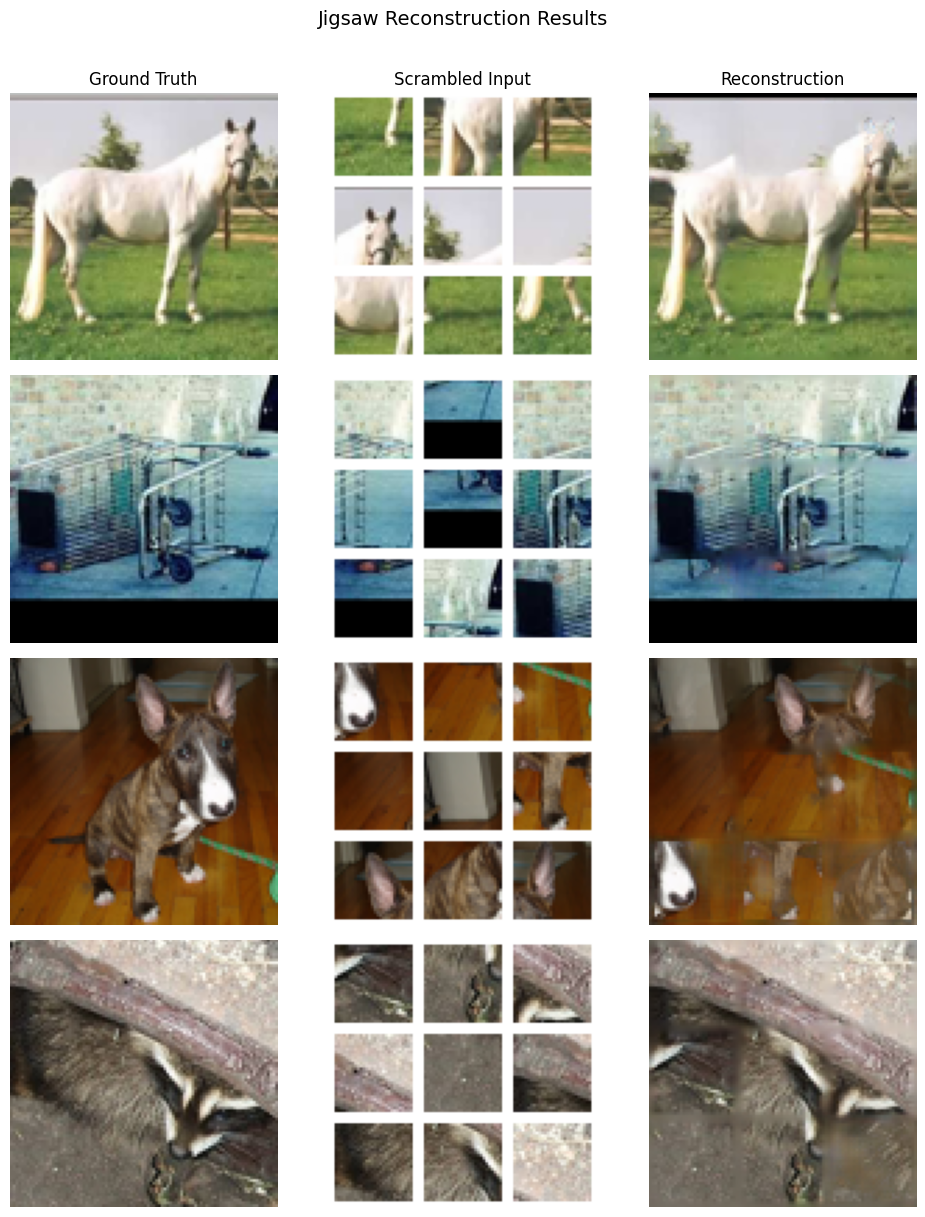

In [ ]:
N_SHOW = 4
X_vis, Y_vis = test_generator.__getitem__(10)
preds = model(X_vis[:N_SHOW], training=False).numpy()

fig, axes = plt.subplots(N_SHOW, 3, figsize=(10, 3 * N_SHOW))
for idx in range(N_SHOW):
    # Ground truth
    axes[idx, 0].imshow(Y_vis[idx]); axes[idx, 0].axis('off')
    if idx == 0: axes[idx, 0].set_title("Ground Truth", fontsize=12)

    # Scrambled patches (no ordering)
    canvas = np.ones((96, 96, 3), dtype=np.float32)
    for slot in range(9):
        r, c = slot // 3, slot % 3
        y0, x0 = r * 32 + 2, c * 32 + 2
        canvas[y0:y0+28, x0:x0+28] = X_vis[idx, slot]
    axes[idx, 1].imshow(canvas); axes[idx, 1].axis('off')
    if idx == 0: axes[idx, 1].set_title("Scrambled Input", fontsize=12)

    # Reconstruction
    axes[idx, 2].imshow(preds[idx]); axes[idx, 2].axis('off')
    mae_i = float(np.mean(np.abs(preds[idx] - Y_vis[idx])))
    if idx == 0: axes[idx, 2].set_title("Reconstruction", fontsize=12)
    axes[idx, 2].set_xlabel(f"MAE={mae_i:.4f}", fontsize=9)

plt.suptitle("Jigsaw Reconstruction Results", y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

## 7. Saving & Downloading Model Weights

The trained weights are saved as a Keras `.keras` file.
Upload the file to Google Drive and create a shareable link, then use `gdown` for reproducible access.

**To generate the download link:**
1. Run the cell below to save and download the weights file from Colab
2. Upload `best_jigsaw_weights.keras` to Google Drive
3. Right-click → "Share" → "Anyone with the link" → "Viewer"
4. Copy the file ID from the URL (format: `https://drive.google.com/file/d/<FILE_ID>/view`)
5. Replace `<FILE_ID>` in the verification cell below

### Download the `.keras` file

In [ ]:
import os
from google.colab import files

keras_weights_filename = 'best_jigsaw_weights.keras'

# Check if the .keras file exists
if os.path.exists(keras_weights_filename):
    files.download(keras_weights_filename)
    print(f"Download triggered for {keras_weights_filename}.")
else:
    print(f"File {keras_weights_filename} not found. Please ensure training completed successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered for best_jigsaw_weights.keras.


### Verification cell — load weights from Google Drive


In [ ]:
import subprocess, os

GDRIVE_FILE_ID = "1FacA61RHZK0xAKemJPV1lteCgj9n-NDW"

if GDRIVE_FILE_ID != " 1FacA61RHZK0xAKemJPV1lteCgj9n-NDW ":
    # Download weights using gdown
    result = subprocess.run(
        ["pip", "install", "-q", "gdown"], capture_output=True
    )
    import gdown
    url = f"https://drive.google.com/uc?id={GDRIVE_FILE_ID}"
    gdown.download(url, "loaded_weights.keras", quiet=False)

    # Rebuild the model from scratch and load weights
    model_check = build_full_model()
    model_check.load_weights("loaded_weights.keras")

    # Quick forward pass verification
    dummy_check = tf.random.normal((1, 9, 28, 28, 3))
    out_check = model_check(dummy_check, training=False)
    assert out_check.shape == (1, 96, 96, 3), "Shape mismatch!"
    print("✓ Weights loaded successfully from Google Drive")
    print(f"  Output shape: {out_check.shape}")
else:
    print("⚠  Please replace <FILE_ID> with your Google Drive file ID.")

Downloading...
From (original): https://drive.google.com/uc?id=1FacA61RHZK0xAKemJPV1lteCgj9n-NDW
From (redirected): https://drive.google.com/uc?id=1FacA61RHZK0xAKemJPV1lteCgj9n-NDW&confirm=t&uuid=a6e373c6-aec1-48ed-bc75-726e3e636769
To: /content/loaded_weights.keras
100%|██████████| 66.5M/66.5M [00:00<00:00, 205MB/s]


✓ Weights loaded successfully from Google Drive
  Output shape: (1, 96, 96, 3)


# ***Evaulation of The trained model loaded from Google Drive***

Downloading...
From (original): https://drive.google.com/uc?id=1FacA61RHZK0xAKemJPV1lteCgj9n-NDW
From (redirected): https://drive.google.com/uc?id=1FacA61RHZK0xAKemJPV1lteCgj9n-NDW&confirm=t&uuid=40c348e7-2e96-4c85-a358-21597d4f9bb7
To: /content/loaded_jigsaw_weights.keras
100%|██████████| 66.5M/66.5M [00:00<00:00, 166MB/s]


Downloaded weights: loaded_jigsaw_weights.keras
Model weights loaded successfully.
Input shape : (1, 9, 28, 28, 3)
Output shape: (1, 96, 96, 3)
Target shape: (1, 96, 96, 3)
Forward pass OK.
Test MAE : 0.048175
Test STD : 0.009343


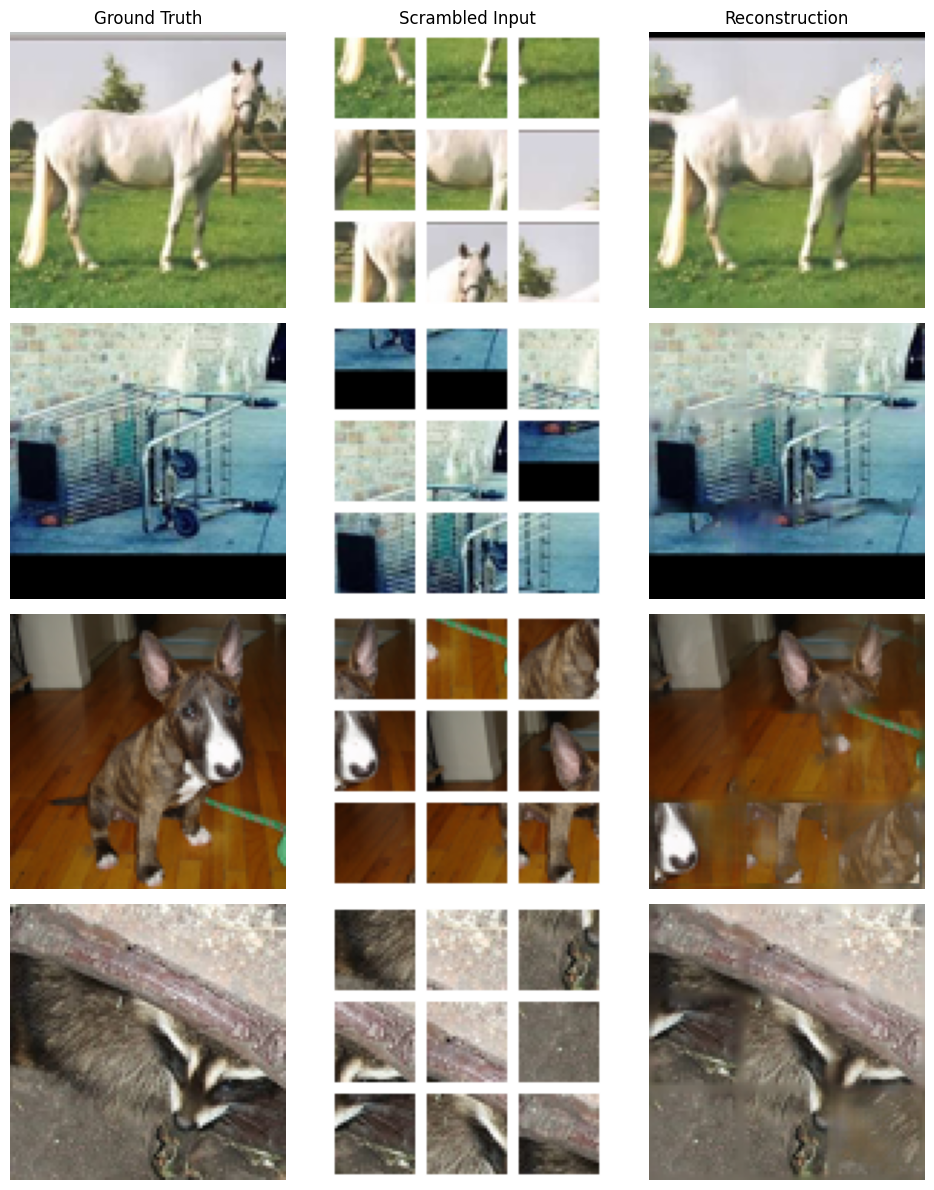

In [ ]:

import os
import re
import gdown
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Google Drive weight file
# ------------------------------------------------------------
GDRIVE_FILE_ID_OR_URL = "1FacA61RHZK0xAKemJPV1lteCgj9n-NDW"

LOCAL_WEIGHTS_PATH = "loaded_jigsaw_weights.keras"


def extract_drive_id(x):
    """Accepts a Google Drive file ID or a full Drive URL."""
    if "drive.google.com" not in x:
        return x.strip()

    patterns = [
        r"/d/([^/]+)",
        r"id=([^&]+)"
    ]

    for p in patterns:
        m = re.search(p, x)
        if m:
            return m.group(1)

    raise ValueError("Could not extract Google Drive file ID from URL.")


file_id = extract_drive_id(GDRIVE_FILE_ID_OR_URL)
download_url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(download_url, LOCAL_WEIGHTS_PATH, quiet=False)

assert os.path.exists(LOCAL_WEIGHTS_PATH), "Weights download failed!"

print("Downloaded weights:", LOCAL_WEIGHTS_PATH)


# ------------------------------------------------------------
# 2. Rebuild the exact same model architecture
# ------------------------------------------------------------
loaded_model = build_full_model()

# Load weights
loaded_model.load_weights(LOCAL_WEIGHTS_PATH)

loaded_model.compile(
    optimizer="adam",
    loss="mae",
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
)

print("Model weights loaded successfully.")


# ------------------------------------------------------------
# 3. Quick forward-pass test
# ------------------------------------------------------------
X_check, Y_check = test_generator[0]
pred_check = loaded_model(X_check[:1], training=False)

print("Input shape :", X_check[:1].shape)
print("Output shape:", pred_check.shape)
print("Target shape:", Y_check[:1].shape)

assert pred_check.shape == (1, 96, 96, 3), "Output shape is incorrect!"

print("Forward pass OK.")


# ------------------------------------------------------------
# 4. Full test-set evaluation
# ------------------------------------------------------------
batch_maes = []

for i in range(len(test_generator)):
    X_b, Y_b = test_generator[i]

    preds = loaded_model(X_b, training=False).numpy()

    # True per-batch MAE
    batch_mae = np.mean(np.abs(preds - Y_b))
    batch_maes.append(batch_mae)

test_mae = float(np.mean(batch_maes))
test_std = float(np.std(batch_maes))

print("=" * 50)
print(f"Test MAE : {test_mae:.6f}")
print(f"Test STD : {test_std:.6f}")
print("=" * 50)


# ------------------------------------------------------------
# 5. Visualize predictions
# ------------------------------------------------------------
N_SHOW = 4

X_vis, Y_vis = test_generator[10]
preds = loaded_model(X_vis[:N_SHOW], training=False).numpy()

fig, axes = plt.subplots(N_SHOW, 3, figsize=(10, 3 * N_SHOW))

for idx in range(N_SHOW):
    # Ground truth
    axes[idx, 0].imshow(Y_vis[idx])
    axes[idx, 0].axis("off")
    if idx == 0:
        axes[idx, 0].set_title("Ground Truth")

    # Scrambled input canvas
    canvas = np.ones((96, 96, 3), dtype=np.float32)

    for slot in range(9):
        r, c = slot // 3, slot % 3
        y0, x0 = r * 32 + 2, c * 32 + 2
        canvas[y0:y0 + 28, x0:x0 + 28] = X_vis[idx, slot]

    axes[idx, 1].imshow(canvas)
    axes[idx, 1].axis("off")
    if idx == 0:
        axes[idx, 1].set_title("Scrambled Input")

    # Reconstruction
    mae_i = np.mean(np.abs(preds[idx] - Y_vis[idx]))

    axes[idx, 2].imshow(np.clip(preds[idx], 0, 1))
    axes[idx, 2].axis("off")
    axes[idx, 2].set_xlabel(f"MAE={mae_i:.4f}")

    if idx == 0:
        axes[idx, 2].set_title("Reconstruction")

plt.tight_layout()
plt.show()

## 8. Summary

| Item | Value |
|------|-------|
| **Architecture** | CNN Encoder + 4-layer Transformer + Sinkhorn Head + U-Net Refinement |
| **Total parameters** | 5,509,260 |
| **Parameter budget** | < 6,000,000 ✓ |
| **Pretrained weights** | None ✓ |
| **Framework** | Keras / TensorFlow ✓ |
| **Loss / metric** | Mean Absolute Error (MAE) |
| **Baseline MAE** | *(see output above)* |
| **Model MAE** | *(see output above)* |
| **Weights download** | `gdown` from Google Drive *(update FILE_ID above)* |

### Key Design Decisions

- **Shared encoder** ensures permutation-equivariance at the feature level — the model doesn't assume any input ordering
- **Sinkhorn operator** provides a differentiable, doubly-stochastic assignment matrix that can be trained end-to-end with MAE loss, without needing Hungarian matching
- **Residual connection** in the U-Net refinement head means the model only learns the *correction* to the assembled canvas, not the full image from scratch — faster convergence
- **U-Net skip connections** preserve fine-grained texture from the known patch regions while allowing the bottleneck to reason about missing borders